# <span style="color:red"> Lecture 18 - Time Data </span>

<font size = "4">

In this class we will ...

- Process time series data in Python and Pandas
- Introduce new datatype for time
- Plot multiple series
- Compute growth rates

First, let's import the libraries we'll need, and load in the data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


df_financial = pd.read_csv("data_raw/financial.csv")

<font size = "4">

The data can be downloaded from [FRED (Federal Reserve Bank of St. Louis)](https://fred.stlouisfed.org/categories/32255)

Let's inspect the data, and its dtypes:

In [3]:
display(df_financial.head())
print()
display(df_financial.dtypes)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3
0,4/4/2018,2644.69,24264.30,April 04 2018,"Wednesday, 2018-04-04",4-Apr-18
1,4/5/2018,2662.84,24505.22,April 05 2018,"Thursday, 2018-04-05",5-Apr-18
2,4/6/2018,2604.47,23932.76,April 06 2018,"Friday, 2018-04-06",6-Apr-18
3,4/9/2018,2613.16,23979.10,April 09 2018,"Monday, 2018-04-09",9-Apr-18
4,4/10/2018,2656.87,24408.00,April 10 2018,"Tuesday, 2018-04-10",10-Apr-18


date_str     object
sp500       float64
djia        float64
date_ex1     object
date_ex2     object
date_ex3     object
dtype: object

<font size = "4">

The columns represent:

- First column: date (month, day, year)
- Second column: the S&P 500 stock market index
- Third column: the Dow Jones Industrial Average stock market index
- Columns 4, 5, 6: Other representations of the date. We will discuss them next lecture

<font size = "4">

Notice that the data is ordered from oldest to newest:

In [4]:
print(df_financial["date_str"].iloc[0])
print(df_financial["date_str"].iloc[1])
print("...")
print(df_financial["date_str"].iloc[-2])
print(df_financial["date_str"].iloc[-1])

4/4/2018
4/5/2018
...
4/3/2023
4/4/2023


<font size = "4">

**Question:** What if I want the data arranged in the other order (newest first)? How can I use ``.sort_values()`` to re-order the data?

In [5]:
# Use .sort_values() to sort data newest to oldest

df_financial = df_financial.sort_values(by = "date_str", ascending = False)

# didnt work

<font size = "4">

If you try to sort dates that are represented by *strings*, they will be sorted "lexicographically" (alphabetically).

The strings representing the dates must be converted to a new datatype, the ``datetime`` format.

This can be done with the Pandas function ``to_datetime``

In [6]:
# Use the Pandas datetime to convert the column to datetime format 
# We'll add a new column to the DataFrame

df_financial["date"] = pd.to_datetime(df_financial["date_str"])

<font size = "4">

Let's check the DataTypes again

In [7]:
display(df_financial.dtypes)

date_str            object
sp500              float64
djia               float64
date_ex1            object
date_ex2            object
date_ex3            object
date        datetime64[ns]
dtype: object

<font size = "4">

Compare with the types of the column elements:

In [8]:
print(type(df_financial['date_str'].iloc[0]))
print(type(df_financial['sp500'].iloc[0]))
print(type(df_financial['date'].iloc[0])) 

<class 'str'>
<class 'numpy.float64'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


<font size = "4">

- So the "date" column has the datatype ``datetime64[ns]``, but its elements are Pandas ``Timestamp`` objects.

- ????

- There is a difference between how Pandas stores data "internally" and when you extract parts of the data.

- We've actually seen this before. Note that the "date_str" column has the datatype ``object``, but its elements are ``str`` (strings).

Regardless, now that we have converted the dates to an appropriate datatype, we can now sort them sensibly!

In [9]:
# sort df_financial by the "date" column

df_financial = df_financial.sort_values(by = "date", ascending = False)

<font size = "4">

How can I plot time vs. the S&P 500 index?

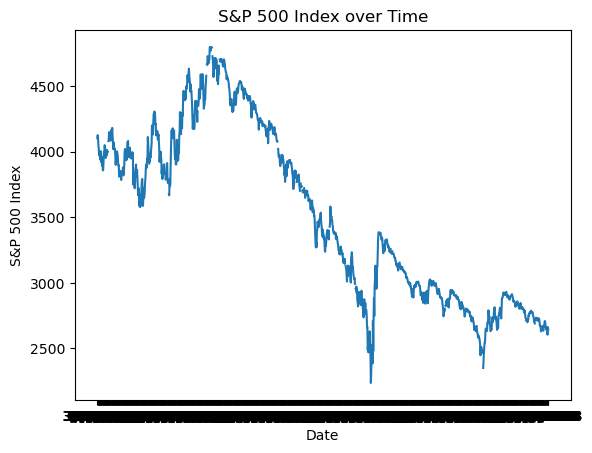

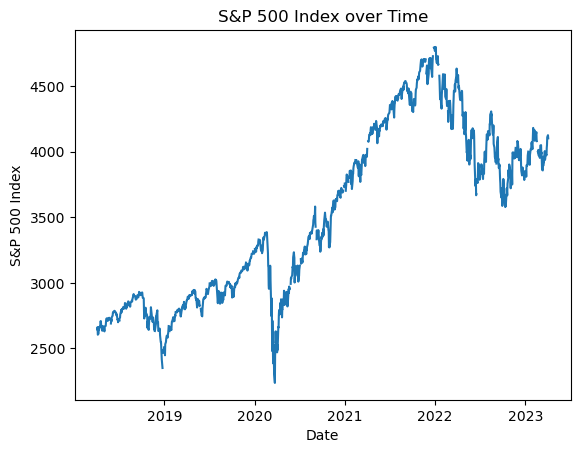

In [10]:
# Goal: plot date (x-axis) vs. S&P 500 (y-axis)

x_vals = df_financial["date_str"]
y_vals = df_financial["sp500"]
plt.plot(x_vals, y_vals)
# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("S&P 500 Index")
# title
plt.title("S&P 500 Index over Time")

plt.show()

x_vals = df_financial["date"]
y_vals = df_financial["sp500"]
plt.plot(x_vals, y_vals)
# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("S&P 500 Index")
# title
plt.title("S&P 500 Index over Time")

plt.show()


<font size = "4">

So there's another advantage of converting to ``datetime`` objects...plots look much better!

**Note**: ``matplotlib.pyplot.plot`` has compatibility with Pandas DataFrames:

In [11]:
# Another way of using plt.plot with the "data" argument



<font size = "4">

**Important:** Whatever variable you put on the x-axis, the data better be sorted by that variable!!

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date
513,3/23/2020,2237.40,18591.93,March 23 2020,"Monday, 2020-03-23",23-Mar-20,2020-03-23
512,3/20/2020,2304.92,19173.98,March 20 2020,"Friday, 2020-03-20",20-Mar-20,2020-03-20
188,12/24/2018,2351.10,21792.20,December 24 2018,"Monday, 2018-12-24",24-Dec-18,2018-12-24
508,3/16/2020,2386.13,20188.52,March 16 2020,"Monday, 2020-03-16",16-Mar-20,2020-03-16
510,3/18/2020,2398.10,19898.92,March 18 2020,"Wednesday, 2020-03-18",18-Mar-20,2020-03-18
...,...,...,...,...,...,...,...
175,12/5/2018,NaN,NaN,December 05 2018,"Wednesday, 2018-12-05",5-Dec-18,2018-12-05
166,11/22/2018,NaN,NaN,November 22 2018,"Thursday, 2018-11-22",22-Nov-18,2018-11-22
108,9/3/2018,NaN,NaN,September 03 2018,"Monday, 2018-09-03",3-Sep-18,2018-09-03
65,7/4/2018,NaN,NaN,July 04 2018,"Wednesday, 2018-07-04",4-Jul-18,2018-07-04


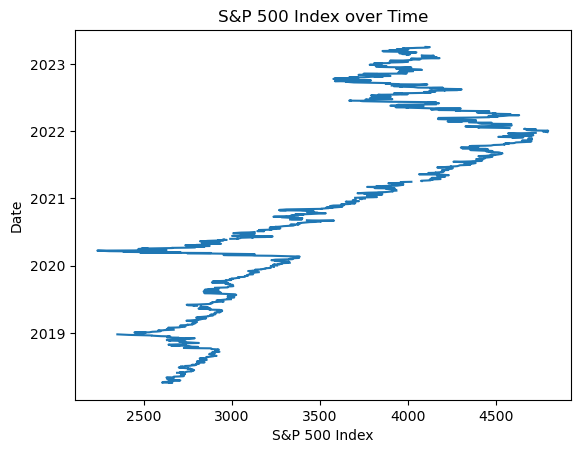

In [12]:
df_sorted = df_financial.sort_values(by = "sp500")
display(df_sorted)

# try plotting date vs. sp500 for df_sorted

x_vals = df_financial["sp500"]
y_vals = df_financial["date"]
plt.plot(x_vals, y_vals)
# label x-axis
plt.xlabel("S&P 500 Index")
# label y-axis
plt.ylabel("Date")
# title
plt.title("S&P 500 Index over Time")

plt.show()


<font size = "4">

**Exercise:**

How would I generate a plot of time vs. Dow Jones Industrial Average?

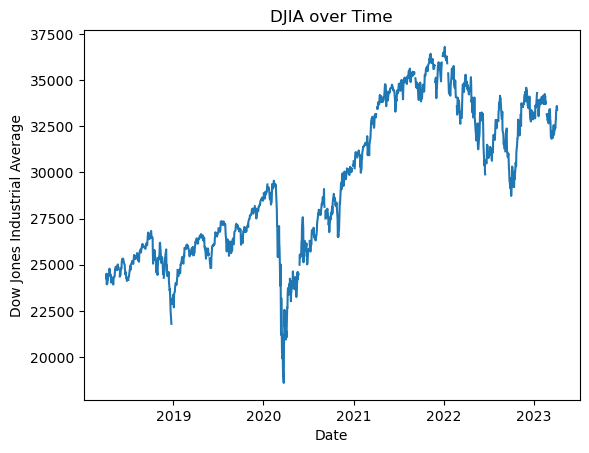

In [13]:
# Write your own code


x_vals = df_financial["date"]
y_vals = df_financial["djia"]
plt.plot(x_vals, y_vals)
# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("Dow Jones Industrial Average")
# title
plt.title("DJIA over Time")

plt.show()

<font size = "4">

- How do we plot multiple columns of the dataset? 
- For instance, let's plot both time vs. S&P 500 and time vs. Dow Jones
- Each DataFrame has its own ``.plot`` method.

In [ ]:
# Step 1 of chain:
# Grab columns we want to plot

df_financial[["date", "sp500", "djia"]]

# why two brackets

# Syntax	                       What it selects	    Return type
# df["sp500"]	                   One column	        Series
# df[["sp500"]]	                   One column(as df)    DataFrame
# df[["date", "sp500", "djia"]]	   Multiple columns	    DataFrame

,date,sp500,djia
1304,2023-04-04,4100.60,33402.38
1303,2023-04-03,4124.51,33601.15
1302,2023-03-31,4109.31,33274.15
1301,2023-03-30,4050.83,32859.03
1300,2023-03-29,4027.81,32717.60
...,...,...,...
4,2018-04-10,2656.87,24408.00
3,2018-04-09,2613.16,23979.10
2,2018-04-06,2604.47,23932.76
1,2018-04-05,2662.84,24505.22


In [24]:
# Step 2 of chain:
# We will plot the date on the x-axis.
# So we will make "date" the index column

df_financial[["date", "sp500", "djia"]].set_index("date")

,sp500,djia
date,,
2023-04-04,4100.60,33402.38
2023-04-03,4124.51,33601.15
2023-03-31,4109.31,33274.15
2023-03-30,4050.83,32859.03
2023-03-29,4027.81,32717.60
...,...,...
2018-04-10,2656.87,24408.00
2018-04-09,2613.16,23979.10
2018-04-06,2604.47,23932.76


<Axes: xlabel='date'>

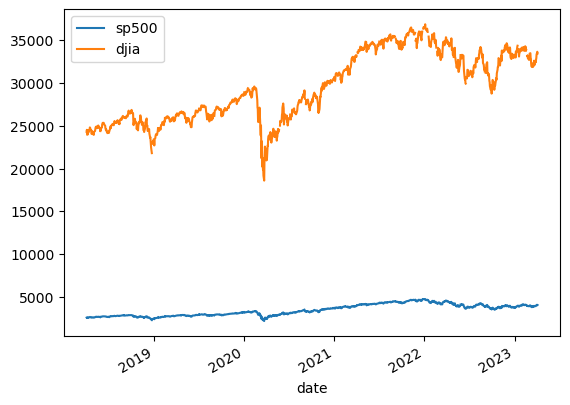

In [ ]:
# Step 3 of chain:
# We will use the DataFrame's .plot method.
# This will plot index vs. column 1 AND
# will plot index vs. column 2

df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()

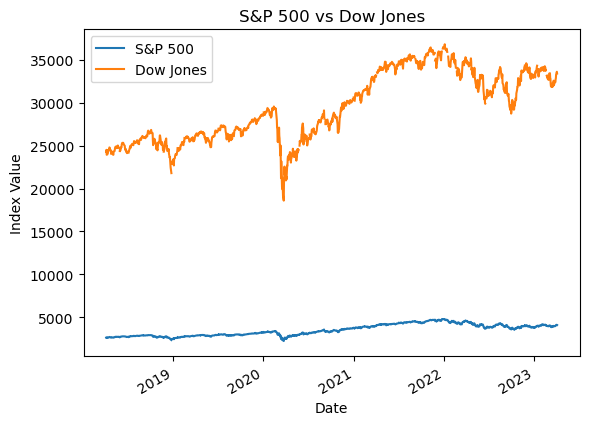

In [22]:
# .plot() used column names for the legend and x-axis.
# Here's how to adjust them ourselves

df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()

plt.xlabel("Date")                       # Change x-axis label
plt.ylabel("Index Value")                # Change y-axis label
plt.title("S&P 500 vs Dow Jones")        # Add chart title
plt.legend(["S&P 500", "Dow Jones"]) 

plt.show()


<font size = "4">

The S&P 500 and Dow Jones have different units. Should either:

- Convert one to the other's units
- Have a left and right y-axis, one for each variable (more on this in a future lecture).
- Plot a "unitless" or "non-dimensional" measure of both.

The **percentage growth** is a non-dimensional quantity we can calculate for both:

$$\textrm{per. growth} = \frac{(\textrm{today's index}) - (\textrm{yesterday's index})}{\textrm{yesterdays's index}} \times 100\  \%$$

In [25]:
# Let's calculate the numerator: the difference between today's index 
# and yesterday's index.

df_financial["diff_sp500"] = df_financial["sp500"].diff()

df_financial[["date", "sp500", "diff_sp500"]]


,date,sp500,diff_sp500
1304,2023-04-04,4100.60,NaN
1303,2023-04-03,4124.51,23.91
1302,2023-03-31,4109.31,-15.20
1301,2023-03-30,4050.83,-58.48
1300,2023-03-29,4027.81,-23.02
...,...,...,...
4,2018-04-10,2656.87,14.68
3,2018-04-09,2613.16,-43.71
2,2018-04-06,2604.47,-8.69
1,2018-04-05,2662.84,58.37


<font size = "4">

To easily divide by "yesterday's index", we will shift the "sp500" column down, and make it a new column

In [26]:
# Let's make the denominator: "yesterday's index"
# Also known as the "lag"

# ".shift(1)" computes a new column with the value of "sp500"
# one period before. By convention the first column is assigned
# a missing value

df_financial["lag_sp500"] = df_financial["sp500"].shift(1)
display(df_financial[["date", "sp500", "lag_sp500", "diff_sp500"]])



,date,sp500,lag_sp500,diff_sp500
1304,2023-04-04,4100.60,NaN,NaN
1303,2023-04-03,4124.51,4100.60,23.91
1302,2023-03-31,4109.31,4124.51,-15.20
1301,2023-03-30,4050.83,4109.31,-58.48
1300,2023-03-29,4027.81,4050.83,-23.02
...,...,...,...,...
4,2018-04-10,2656.87,2642.19,14.68
3,2018-04-09,2613.16,2656.87,-43.71
2,2018-04-06,2604.47,2613.16,-8.69
1,2018-04-05,2662.84,2604.47,58.37


In [27]:
# Now we combine ".diff()" and ".shift()" to compute growth rates

df_financial["growth_sp500"] = (df_financial["diff_sp500"]/df_financial["lag_sp500"]) * 100
display(df_financial[["date", "growth_sp500", "lag_sp500", "diff_sp500"]])

,date,growth_sp500,lag_sp500,diff_sp500
1304,2023-04-04,NaN,NaN,NaN
1303,2023-04-03,0.583085,4100.60,23.91
1302,2023-03-31,-0.368529,4124.51,-15.20
1301,2023-03-30,-1.423110,4109.31,-58.48
1300,2023-03-29,-0.568279,4050.83,-23.02
...,...,...,...,...
4,2018-04-10,0.555600,2642.19,14.68
3,2018-04-09,-1.645169,2656.87,-43.71
2,2018-04-06,-0.332548,2613.16,-8.69
1,2018-04-05,2.241147,2604.47,58.37


<font size = "4">

Now, we plot the growth rate:

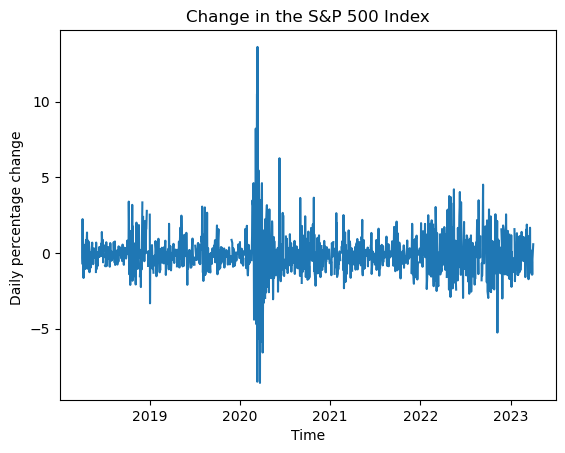

In [28]:
plt.plot("date", "growth_sp500",
          data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the S&P 500 Index")
plt.show()

<font size = "4" >

**Exercise**

- Compute a column with the growth of the Dow Jones
- Plot the growth of the S&P 500 and Dow Jones in a <br>
single plot

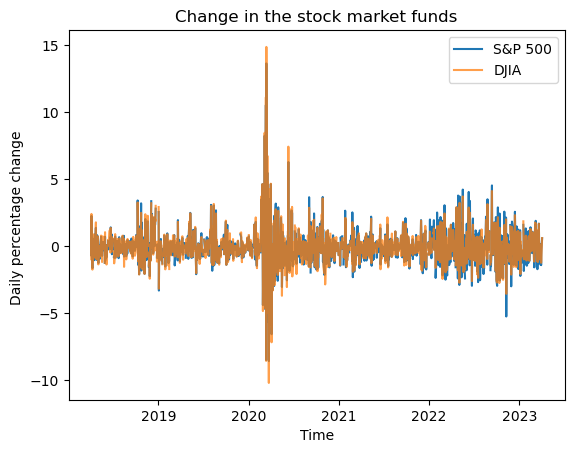

In [29]:
# Write your own code

df_financial["growth_djia"] = (df_financial["djia"].diff()\
         / df_financial["djia"].shift(1) )* 100

plt.plot("date", "growth_sp500",
          data = df_financial)
plt.plot("date", "growth_djia",
          data = df_financial,alpha = 0.75)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the stock market funds")
plt.legend(["S&P 500", "DJIA"])
plt.show()

# <span style="color:red"> III. Subsets of time-series data </span>

<font size = "4" >

Like other DataFrames, we can use ``.query()`` to extract subsets of time-series data. Since we have converted to the "Datetime" datatype, logical conditions can be used in a straightforward way. 

In [30]:
# Since the "date" column has a time format, Python
# will interpret "2019-01-01" as a date inside the query command

subset_before  = df_financial.query('date <= "2019-01-01" ')
subset_after   = df_financial.query('date >= "2019-01-01" ')

display(subset_after)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04,NaN,NaN,NaN,NaN
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03,23.91,4100.60,0.583085,0.595077
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31,-15.20,4124.51,-0.368529,-0.973181
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30,-58.48,4109.31,-1.423110,-1.247575
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29,-23.02,4050.83,-0.568279,-0.430414
...,...,...,...,...,...,...,...,...,...,...,...
198,1/7/2019,2549.69,23531.35,January 07 2019,"Monday, 2019-01-07",7-Jan-19,2019-01-07,-24.72,2574.41,-0.960220,-1.076618
197,1/4/2019,2531.94,23433.16,January 04 2019,"Friday, 2019-01-04",4-Jan-19,2019-01-04,-17.75,2549.69,-0.696163,-0.417273
196,1/3/2019,2447.89,22686.22,January 03 2019,"Thursday, 2019-01-03",3-Jan-19,2019-01-03,-84.05,2531.94,-3.319589,-3.187534
195,1/2/2019,2510.03,23346.24,January 02 2019,"Wednesday, 2019-01-02",2-Jan-19,2019-01-02,62.14,2447.89,2.538513,2.909343


<font size = "4">

Here are some other subsets we might be interested in:

In [34]:
# Beginning of Covid pandemic (independent of data)
subset_between = df_financial.query("'2020-03-01' <= date <= '2020-05-01'")
display(subset_between)
# large changes in percentage growth (positive or negative)
subset_large_change = df_financial.query("growth_sp500 > 5 or growth_sp500 < -5")
display(subset_large_change)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia
542,5/1/2020,2830.71,23723.69,May 01 2020,"Friday, 2020-05-01",1-May-20,2020-05-01,-12.03,2842.74,-0.423183,-0.109770
541,4/30/2020,2912.43,24345.72,April 30 2020,"Thursday, 2020-04-30",30-Apr-20,2020-04-30,81.72,2830.71,2.886908,2.621978
540,4/29/2020,2939.51,24633.86,April 29 2020,"Wednesday, 2020-04-29",29-Apr-20,2020-04-29,27.08,2912.43,0.929808,1.183535
539,4/28/2020,2863.39,24101.55,April 28 2020,"Tuesday, 2020-04-28",28-Apr-20,2020-04-28,-76.12,2939.51,-2.589547,-2.160887
538,4/27/2020,2878.48,24133.78,April 27 2020,"Monday, 2020-04-27",27-Apr-20,2020-04-27,15.09,2863.39,0.526998,0.133726
537,4/24/2020,2836.74,23775.27,April 24 2020,"Friday, 2020-04-24",24-Apr-20,2020-04-24,-41.74,2878.48,-1.450071,-1.485511
536,4/23/2020,2797.80,23515.26,April 23 2020,"Thursday, 2020-04-23",23-Apr-20,2020-04-23,-38.94,2836.74,-1.372702,-1.093615
535,4/22/2020,2799.31,23475.82,April 22 2020,"Wednesday, 2020-04-22",22-Apr-20,2020-04-22,1.51,2797.80,0.053971,-0.167721
534,4/21/2020,2736.56,23018.88,April 21 2020,"Tuesday, 2020-04-21",21-Apr-20,2020-04-21,-62.75,2799.31,-2.241624,-1.946428
533,4/20/2020,2823.16,23650.44,April 20 2020,"Monday, 2020-04-20",20-Apr-20,2020-04-20,86.60,2736.56,3.164557,2.743661


,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia
1200,11/9/2022,3748.57,32513.94,November 09 2022,"Wednesday, 2022-11-09",9-Nov-22,2022-11-09,-207.80,3956.37,-5.252289,-3.563449
570,6/10/2020,3190.14,26989.99,June 10 2020,"Wednesday, 2020-06-10",10-Jun-20,2020-06-10,188.04,3002.10,6.263615,7.409294
522,4/3/2020,2488.65,21052.53,April 03 2020,"Friday, 2020-04-03",3-Apr-20,2020-04-03,-175.03,2663.68,-6.570985,-7.175753
515,3/25/2020,2475.56,21200.55,March 25 2020,"Wednesday, 2020-03-25",25-Mar-20,2020-03-25,-154.51,2630.07,-5.874749,-5.993304
513,3/23/2020,2237.40,18591.93,March 23 2020,"Monday, 2020-03-23",23-Mar-20,2020-03-23,-209.93,2447.33,-8.577920,-10.205212
509,3/17/2020,2529.19,21237.38,March 17 2020,"Tuesday, 2020-03-17",17-Mar-20,2020-03-17,131.09,2398.10,5.466411,6.726295
508,3/16/2020,2386.13,20188.52,March 16 2020,"Monday, 2020-03-16",16-Mar-20,2020-03-16,-143.06,2529.19,-5.656356,-4.938745
507,3/13/2020,2711.02,23185.62,March 13 2020,"Friday, 2020-03-13",13-Mar-20,2020-03-13,324.89,2386.13,13.615771,14.845566
506,3/12/2020,2480.64,21200.62,March 12 2020,"Thursday, 2020-03-12",12-Mar-20,2020-03-12,-230.38,2711.02,-8.497909,-8.561341
505,3/11/2020,2741.38,23553.22,March 11 2020,"Wednesday, 2020-03-11",11-Mar-20,2020-03-11,260.74,2480.64,10.510997,11.096845


In [35]:
# alternate way. 
# Datetime objects have a ".between()" method

subset_between = df_financial.query("date.between('2020-03-01', '2020-05-01') ")
subset_between


,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia
542,5/1/2020,2830.71,23723.69,May 01 2020,"Friday, 2020-05-01",1-May-20,2020-05-01,-12.03,2842.74,-0.423183,-0.109770
541,4/30/2020,2912.43,24345.72,April 30 2020,"Thursday, 2020-04-30",30-Apr-20,2020-04-30,81.72,2830.71,2.886908,2.621978
540,4/29/2020,2939.51,24633.86,April 29 2020,"Wednesday, 2020-04-29",29-Apr-20,2020-04-29,27.08,2912.43,0.929808,1.183535
539,4/28/2020,2863.39,24101.55,April 28 2020,"Tuesday, 2020-04-28",28-Apr-20,2020-04-28,-76.12,2939.51,-2.589547,-2.160887
538,4/27/2020,2878.48,24133.78,April 27 2020,"Monday, 2020-04-27",27-Apr-20,2020-04-27,15.09,2863.39,0.526998,0.133726
537,4/24/2020,2836.74,23775.27,April 24 2020,"Friday, 2020-04-24",24-Apr-20,2020-04-24,-41.74,2878.48,-1.450071,-1.485511
536,4/23/2020,2797.80,23515.26,April 23 2020,"Thursday, 2020-04-23",23-Apr-20,2020-04-23,-38.94,2836.74,-1.372702,-1.093615
535,4/22/2020,2799.31,23475.82,April 22 2020,"Wednesday, 2020-04-22",22-Apr-20,2020-04-22,1.51,2797.80,0.053971,-0.167721
534,4/21/2020,2736.56,23018.88,April 21 2020,"Tuesday, 2020-04-21",21-Apr-20,2020-04-21,-62.75,2799.31,-2.241624,-1.946428
533,4/20/2020,2823.16,23650.44,April 20 2020,"Monday, 2020-04-20",20-Apr-20,2020-04-20,86.60,2736.56,3.164557,2.743661


In [37]:
# alternate way. 
# (x > 4 or x < -4) is equivalent to |x| > 4

subset_large_change = df_financial.query("abs(growth_sp500) > 5")
subset_large_change

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia
1200,11/9/2022,3748.57,32513.94,November 09 2022,"Wednesday, 2022-11-09",9-Nov-22,2022-11-09,-207.80,3956.37,-5.252289,-3.563449
570,6/10/2020,3190.14,26989.99,June 10 2020,"Wednesday, 2020-06-10",10-Jun-20,2020-06-10,188.04,3002.10,6.263615,7.409294
522,4/3/2020,2488.65,21052.53,April 03 2020,"Friday, 2020-04-03",3-Apr-20,2020-04-03,-175.03,2663.68,-6.570985,-7.175753
515,3/25/2020,2475.56,21200.55,March 25 2020,"Wednesday, 2020-03-25",25-Mar-20,2020-03-25,-154.51,2630.07,-5.874749,-5.993304
513,3/23/2020,2237.40,18591.93,March 23 2020,"Monday, 2020-03-23",23-Mar-20,2020-03-23,-209.93,2447.33,-8.577920,-10.205212
509,3/17/2020,2529.19,21237.38,March 17 2020,"Tuesday, 2020-03-17",17-Mar-20,2020-03-17,131.09,2398.10,5.466411,6.726295
508,3/16/2020,2386.13,20188.52,March 16 2020,"Monday, 2020-03-16",16-Mar-20,2020-03-16,-143.06,2529.19,-5.656356,-4.938745
507,3/13/2020,2711.02,23185.62,March 13 2020,"Friday, 2020-03-13",13-Mar-20,2020-03-13,324.89,2386.13,13.615771,14.845566
506,3/12/2020,2480.64,21200.62,March 12 2020,"Thursday, 2020-03-12",12-Mar-20,2020-03-12,-230.38,2711.02,-8.497909,-8.561341
505,3/11/2020,2741.38,23553.22,March 11 2020,"Wednesday, 2020-03-11",11-Mar-20,2020-03-11,260.74,2480.64,10.510997,11.096845


<font size = "4">

Once we have identified an interesting subset of the data, we might want to visualize it within the context of the original time-series. For example, we might want to **highlight** these regions after plotting the entire series.

We can do this using the ``fill_between`` function from the ``matplotlib.pyplot`` library

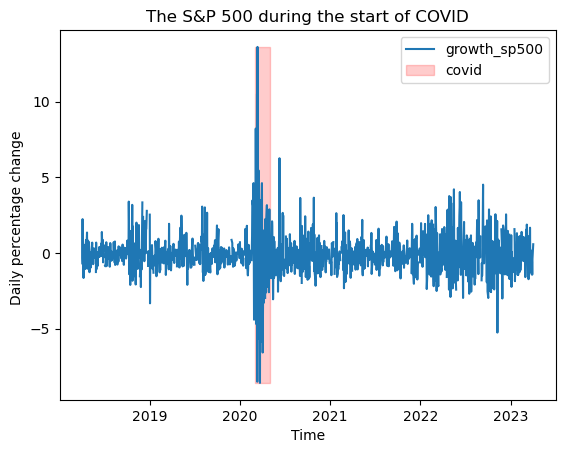

In [45]:
# Create a line plot
plt.plot("date", "growth_sp500", data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("The S&P 500 during the start of COVID")

# Add a shaded region wth a rectangle
# "x" is the x-coordinates, "y1" and "y2" are the lower
# and upper bounds of the rectangle. We can set this
# to be the minimum and maximum of the outcome.
# we use "where" to test a logical condition

x_vals = df_financial["date"]
y_vals = df_financial["growth_sp500"]
condition = df_financial["date"].between("2020-03-01","2020-05-01")

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red", label = "covid")

plt.legend()
plt.show()

<font size = "4">

- If we want to repeatedly refer to this region of the data, it might be a good idea to add a column to the DataFrame which will indicate which rows are part of the range.

- We can "flag" the data, and add a column of Boolean type to the DataFrame

In [39]:
# Add a column called "covid_period" of Boolean type.
# "True" if date is between March 1st, 2020 and May 1st, 2020
df_financial["covid_period"]  = df_financial["date"].between("2020-03-01","2020-05-01")

display(df_financial.head())
display(df_financial.dtypes)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia,covid_period
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04,NaN,NaN,NaN,NaN,False
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03,23.91,4100.60,0.583085,0.595077,False
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31,-15.20,4124.51,-0.368529,-0.973181,False
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30,-58.48,4109.31,-1.423110,-1.247575,False
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29,-23.02,4050.83,-0.568279,-0.430414,False


date_str                object
sp500                  float64
djia                   float64
date_ex1                object
date_ex2                object
date_ex3                object
date            datetime64[ns]
diff_sp500             float64
lag_sp500              float64
growth_sp500           float64
growth_djia            float64
covid_period              bool
dtype: object

<font size = "4">

**Exercise**

- Generate a plot of the percentage growth rate of the Dow Jones 
- Highlight regions where there was growth higher than 3\%
or below -3\%

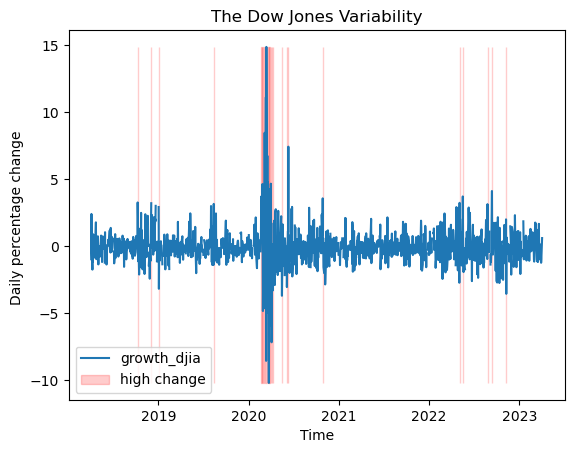

In [44]:
# Create a line plot

plt.plot("date", "growth_djia", data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("The Dow Jones Variability")

x_vals = df_financial["date"]
y_vals = df_financial["growth_djia"]

condition = abs(df_financial["growth_djia"]) > 3

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red", label = "high change")

plt.legend()
plt.show()